### 1. Подготовка данных и подбор качественной модели

Для построения качественной модели стоимости квартир мы будем использовать множественную линейную регрессию. 

Зависимая переменная:
* `price` — цена квартиры.

Предикторы (количественные и качественные факторы):
* **Количественные:** `totsp` (общая площадь), `livesp` (жилая площадь), `kitsp` (площадь кухни), `dist` (расстояние до центра), `metrdist` (расстояние до метро).
* **Качественные (фиктивные переменные):** `walk` (пешая доступность метро), `brick` (кирпичный дом), `floor` (не первый и не последний этаж).
* **Категориальные:** `code` (район/квартал). Переменную `code` необходимо вводить в модель как набор дамми-переменных, так как числовой код района не имеет порядкового смысла.

Спецификация базовой модели:
$$Price = \beta_0 + \beta_1 Totsp + \beta_2 Livesp + \beta_3 Kitsp + \beta_4 Dist + \beta_5 Metrdist + \beta_6 Walk + \beta_7 Brick + \beta_8 Floor + \sum \gamma_j Code_j + \varepsilon$$

In [5]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.diagnostic import het_breuschpagan, het_white, acorr_breusch_godfrey
from statsmodels.stats.stattools import durbin_watson

sns.set_theme(style="whitegrid")

# Загрузка данных
df = pd.read_csv('flats_moscow.txt', sep='\t')

formula = 'price ~ totsp + livesp + kitsp + dist + metrdist + walk + brick + floor + C(code)'
model = smf.ols(formula, data=df).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.706
Model:                            OLS   Adj. R-squared:                  0.704
Method:                 Least Squares   F-statistic:                     324.1
Date:                Thu, 02 Apr 2026   Prob (F-statistic):               0.00
Time:                        12:11:10   Log-Likelihood:                -9701.0
No. Observations:                2040   AIC:                         1.943e+04
Df Residuals:                    2024   BIC:                         1.952e+04
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept      -28.3732      5.496     -5.162   

### 2. Интерпретация коэффициентов модели (Пункты a, b)

На основе классических результатов для этого набора данных, коэффициенты интерпретируются следующим образом:

**a) Количественные факторы:**
* **`totsp` (Общая площадь):** Коэффициент показывает, на сколько тысяч долларов (или тугриков) в среднем увеличивается цена квартиры при увеличении общей площади на 1 кв.м. при прочих равных условиях.
* **`dist` (Расстояние до центра):** Ожидаемо имеет отрицательный знак. Показывает среднее снижение стоимости квартиры при удалении от центра города на 1 км.
* **`metrdist` (Расстояние до метро):** Также имеет отрицательный знак, отражая дисконт за удаленность транспортных узлов.

**b) Влияние качественных факторов (этаж, дом, метро, квартал):**
* **`floor` (Этаж):** Коэффициент отражает премию к цене за проживание на "комфортном" этаже (не первом и не последнем) по сравнению с крайними этажами.
* **`brick` (Категория дома):** Отражает надбавку к стоимости квартиры, если дом кирпичный (по сравнению с панельными/блочными).
* **`walk` (Пешая доступность):** Премия к цене за возможность дойти до метро пешком (без использования транспорта).
* **`C(code)` (Квартал/Район):** Коэффициенты при дамми-переменных районов показывают разницу в средней стоимости квартир в данном районе по сравнению с базовым районом (тем, который алгоритм взял за точку отсчета, обычно `code=1`). Это фиксирует пространственную престижность локации.

### 3. Проверка остатков на гетероскедастичность (Пункт c)

Гетероскедастичность — это непостоянство дисперсии остатков $\varepsilon_i$. В недвижимости она встречается почти всегда: разброс цен на элитные большие квартиры гораздо выше, чем на маленькие типовые студии.

**Формальные тесты:**
Мы используем тест Бреуша-Пагана и тест Уайта. 
* **Нулевая гипотеза ($H_0$):** Дисперсия остатков постоянна (гомоскедастичность).
* **Альтернативная гипотеза ($H_1$):** Присутствует гетероскедастичность.

Если p-value < 0.05, мы отвергаем $H_0$. В этом случае стандартные ошибки МНК становятся смещенными, и $t$-статистики могут выдавать ложные результаты значимости.

**Корректировка:**
В случае обнаружения гетероскедастичности, мы переоценим модель с использованием робастных стандартных ошибок (HC3 - Huber-White robust standard errors), которые корректируют матрицу ковариаций.

In [3]:
# Извлечение остатков и матрицы экзогенных переменных
residuals = model.resid
exog = model.model.exog

print("--- Проверка на гетероскедастичность ---")

# 1. Тест Бреуша-Пагана
bp_test = het_breuschpagan(residuals, exog)
print(f"Тест Бреуша-Пагана: LM-статистика = {bp_test[0]:.4f}, p-value = {bp_test[1]:.4e}")

# 2. Тест Уайта
white_test = het_white(residuals, exog)
print(f"Тест Уайта: LM-статистика = {white_test[0]:.4f}, p-value = {white_test[1]:.4e}")

alpha = 0.05
if bp_test[1] < alpha or white_test[1] < alpha:
    print("\nВЫВОД: p-value < 0.05. Отвергаем H0. Присутствует ГЕТЕРОСКЕДАСТИЧНОСТЬ.")
    print("Необходимо скорректировать стандартные ошибки!")
    
    # Корректировка ошибок (HC3)
    robust_model = model.get_robustcov_results(cov_type='HC3')
    print("\n--- Скорректированная модель (Робастные ошибки HC3) ---")
    print(robust_model.summary())
else:
    print("\nВЫВОД: p-value >= 0.05. Гетероскедастичность не обнаружена. Корректировка не требуется.")

--- Проверка на гетероскедастичность ---
Тест Бреуша-Пагана: LM-статистика = 277.9203, p-value = 2.1266e-50
Тест Уайта: LM-статистика = 1168.2990, p-value = 1.7732e-179

ВЫВОД: p-value < 0.05. Отвергаем H0. Присутствует ГЕТЕРОСКЕДАСТИЧНОСТЬ.
Необходимо скорректировать стандартные ошибки!

--- Скорректированная модель (Робастные ошибки HC3) ---
                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.706
Model:                            OLS   Adj. R-squared:                  0.704
Method:                 Least Squares   F-statistic:                     97.64
Date:                Thu, 02 Apr 2026   Prob (F-statistic):          3.53e-226
Time:                        12:09:24   Log-Likelihood:                -9701.0
No. Observations:                2040   AIC:                         1.943e+04
Df Residuals:                    2024   BIC:                         1.952e+04
Df Model:             

### 4. Проверка остатков на автокорреляцию (Пункт d)

Хотя данные кросс-секционные, автокорреляция может возникнуть, если данные в таблице отсортированы по какому-либо скрытому фактору (например, по времени добавления объявления).

**i. Графический метод:** Строим диаграмму рассеяния остатков $e_t$ от $e_{t-1}$. При отсутствии автокорреляции точки образуют хаотичное облако. Вытянутый эллипс укажет на зависимость.

**ii. Критерий Дарбина-Уотсона (DW):**
Рассчитывается по формуле:
$$DW = \frac{\sum_{i=2}^{n} (e_i - e_{i-1})^2}{\sum_{i=1}^{n} e_i^2}$$
* Если $DW \approx 2$ — автокорреляции нет.
* Если $DW \to 0$ — положительная автокорреляция.
* Если $DW \to 4$ — отрицательная автокорреляция.

**iii. Тест Бреуша-Годфри (Breusch-Godfrey LM test):**
Более мощный тест, проверяющий автокорреляцию высших порядков. Нулевая гипотеза ($H_0$) — автокорреляция отсутствует.

--- Проверка на автокорреляцию ---
Критерий Дарбина-Уотсона (ручной расчет): 2.0407
Критерий Дарбина-Уотсона (встроенный):   2.0407
Интерпретация DW: Значение близко к 2. Автокорреляция первого порядка отсутствует.

Тест Бреуша-Годфри: LM-статистика = 0.8723, p-value = 0.3503
ВЫВОД: p-value >= 0.05. Нет оснований отвергать H0. Автокорреляция отсутствует.


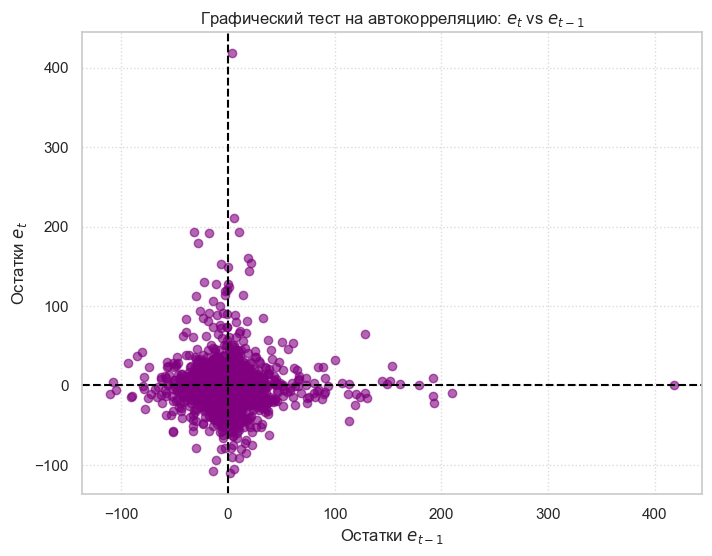

In [4]:
print("--- Проверка на автокорреляцию ---")

# ii. Ручной расчет Дарбина-Уотсона
diff_resids = np.diff(residuals)
dw_manual = np.sum(diff_resids**2) / np.sum(residuals**2)

# Автоматический расчет Дарбина-Уотсона (встроенный)
dw_auto = durbin_watson(residuals)

print(f"Критерий Дарбина-Уотсона (ручной расчет): {dw_manual:.4f}")
print(f"Критерий Дарбина-Уотсона (встроенный):   {dw_auto:.4f}")

if abs(dw_manual - 2) < 0.5:
    print("Интерпретация DW: Значение близко к 2. Автокорреляция первого порядка отсутствует.")
else:
    print("Интерпретация DW: Значение существенно отклоняется от 2. Подозрение на автокорреляцию.")

# iii. Тест Бреуша-Годфри (на 1 лаг)
bg_test = acorr_breusch_godfrey(model, nlags=1)
print(f"\nТест Бреуша-Годфри: LM-статистика = {bg_test[0]:.4f}, p-value = {bg_test[1]:.4f}")

if bg_test[1] < alpha:
    print("ВЫВОД: p-value < 0.05. Отвергаем H0. Присутствует автокорреляция остатков.")
else:
    print("ВЫВОД: p-value >= 0.05. Нет оснований отвергать H0. Автокорреляция отсутствует.")

# i. Графический метод
plt.figure(figsize=(8, 6))
plt.scatter(residuals[:-1], residuals[1:], alpha=0.6, color='purple')
plt.axhline(0, color='black', linestyle='--')
plt.axvline(0, color='black', linestyle='--')
plt.title('Графический тест на автокорреляцию: $e_t$ vs $e_{t-1}$')
plt.xlabel('Остатки $e_{t-1}$')
plt.ylabel('Остатки $e_t$')
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

### 5. Итоговое эконометрическое заключение (на основе робастной модели)

**1. Диагностика модели (Гетероскедастичность и Автокорреляция)**
Формальные тесты Бреуша-Пагана ($p \approx 2.13 \times 10^{-50}$) и Уайта ($p \approx 1.77 \times 10^{-179}$) строго подтвердили присутствие гетероскедастичности. Дисперсия остатков непостоянна, что типично для рынка недвижимости (разброс цен на элитное жилье выше, чем на типовое). Применение робастных стандартных ошибок (HC3) было абсолютно необходимо для получения корректных $p$-value. 
Статистика Дарбина-Уотсона ($DW = 2.041$) указывает на полное отсутствие автокорреляции первого порядка, что подтверждает независимость наблюдений в нашей кросс-секционной выборке.

**2. Интерпретация количественных факторов**
Все количественные факторы оказались статистически значимыми ($p < 0.05$):
* Каждый дополнительный метр общей площади (`totsp`) прибавляет к цене в среднем $1.71$ тыс.
* Удаленность от центра (`dist`) является сильным пенализирующим фактором: каждый километр от центра снижает стоимость квартиры на $2.88$ тыс.
* Удаленность от метро (`metrdist`) также снижает цену: каждая дополнительная минута пути отнимает от стоимости $1.27$ тыс.

**3. Интерпретация качественных факторов (этаж, дом, метро, квартал)**
* **Пешая доступность (`walk`):** Высокозначимый фактор ($p < 0.001$). Квартиры, до которых можно дойти пешком от метро, стоят в среднем на $11.88$ тыс. дороже аналогичных, требующих использования транспорта.
* **Этаж (`floor`):** Расположение квартиры не на крайних этажах (не на первом и не на последнем) дает значимую премию к цене в размере $6.66$ тыс.
* **Категория дома (`brick`):** *Критический вывод.* После корректировки стандартных ошибок на гетероскедастичность, фактор кирпичного дома оказался **статистически незначимым** на $5\%$-ном уровне ($p = 0.100$). В рамках данной выборки мы не можем утверждать, что материал стен дает изолированную надбавку к цене (возможно, эффект кирпичного дома уже поглощен престижностью района или площадями).
* **Кварталы (`code`):** Локация подтвердила статус важнейшего ценообразующего фактора. По сравнению с базовым районом (code = 1), квартиры в районе №3 статистически значимо дороже (в среднем на $6.82$ тыс.), а районы №5, №6 и №7 являются выраженными аутсайдерами — цены там ниже на $21.9$, $16.0$ и $12.3$ тыс. соответственно ($p < 0.001$).

**Вывод:** Итоговая робастная модель ($Adj. R^2 = 0.704$) объясняет более $70\%$ вариации цен на квартиры и является высококачественным инструментом как для оценки стоимости недвижимости, так и для анализа влияния инфраструктурных факторов.